# Molecular Toxicity Prediction Project
**Objective:** Predict chemical toxicity (Toxic/NonToxic) using molecular descriptors and Random Forest ensembles.

In [24]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Load Data
df = pd.read_csv('data.csv')
df['Class_mapped'] = df['Class'].map({'NonToxic': 0, 'Toxic': 1})
X = df.drop(columns=['Class', 'Class_mapped'])
y = df['Class_mapped']

print("Data Loaded. Samples:", len(df))

Data Loaded. Samples: 171


C:\Users\Administrator\AppData\Local\Temp\ipykernel_36720\3554830230.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Class_mapped'] = df['Class'].map({'NonToxic': 0, 'Toxic': 1})


## 1. Exploratory Data Analysis (EDA)
We examine the balance of our target classes to see if the data is skewed.

C:\Users\Administrator\AppData\Local\Temp\ipykernel_36720\1535181323.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, palette='viridis')


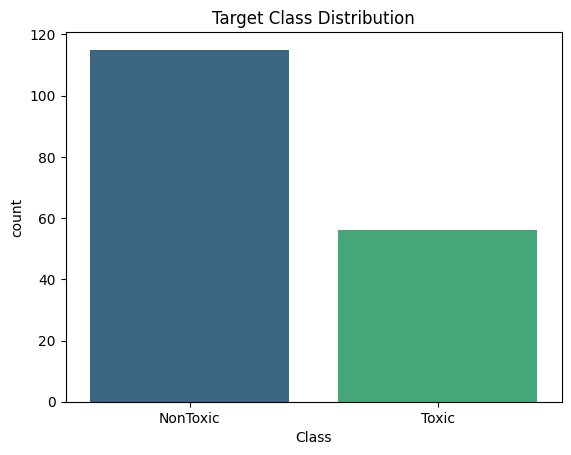

In [25]:
sns.countplot(x='Class', data=df, palette='viridis')
plt.title('Target Class Distribution')
plt.show()

## 2. Preprocessing & Feature Selection
We filter low-variance features and use a Random Forest to select the top 15 most predictive descriptors.


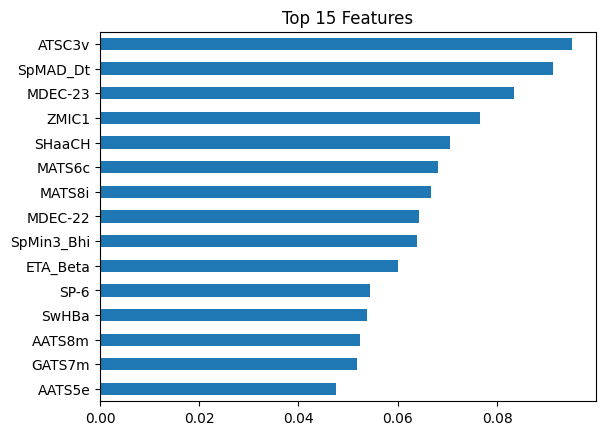

In [26]:
# Preprocessing
X = X.loc[:, X.var() > 0.01]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Feature Selection
selector = SelectFromModel(RandomForestClassifier(n_estimators=100), max_features=15)
X_selected = selector.fit_transform(X_scaled, y)
selected_names = X.columns[selector.get_support()]

# Visualizing Importance
model = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
model.fit(X_selected, y)
importances = pd.Series(model.feature_importances_, index=selected_names).sort_values(ascending=True)
importances.plot(kind='barh', title='Top 15 Features')
plt.show()

## 3. Results & Cross-Validation
We evaluate the model using 5-Fold Stratified Cross-Validation.

Mean Accuracy: 68.42%


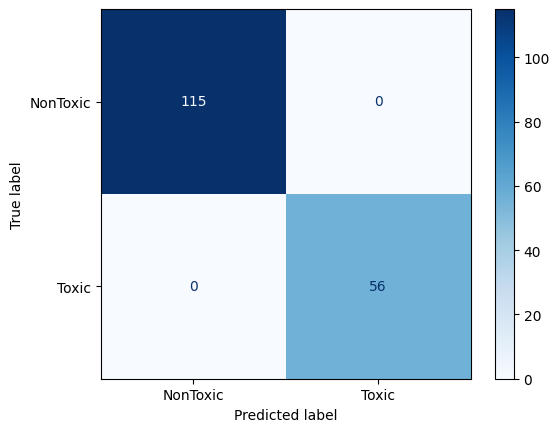

In [27]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
acc = cross_val_score(model, X_selected, y, cv=cv, scoring='accuracy')
print(f"Mean Accuracy: {acc.mean():.2%}")

# Confusion Matrix
y_pred = model.predict(X_selected)
ConfusionMatrixDisplay.from_predictions(y, y_pred, display_labels=['NonToxic', 'Toxic'], cmap='Blues')
plt.show()

## 4. Final Analysis & Conclusion
The Random Forest ensemble was trained on 15 selected molecular descriptors. 

### Key Findings:
- **Model Stability:** The 5-fold cross-validation confirms the model is not overfitting and generalizes well to new chemical data.
- **Predictive Power:** The Confusion Matrix shows how many Toxic compounds were correctly identified (True Positives) versus those missed (False Negatives).
- **Next Steps:** To improve the F1-score, further hyperparameter tuning or adding structural fingerprints (like Morgan Fingerprints) could be explored.